# Model A — `days_to_settle`

Reproduces the training path for **Model A** of Solvent's forecaster stage (Razorpay AI Buildathon, Track 04 — AI Finance Controller) for exploration and documentation. This is an **educational reproduction** of `backend/forecaster/train.py` + `backend/forecaster/features.py` — the canonical production model that the API actually serves is trained by running `python -m backend.forecaster.train` from the repo root, which persists its artifact to `backend/forecaster/models/model_a_days_to_settle.joblib` and its metrics to Postgres (`forecaster_metrics` table). This notebook uses the same algorithm, the same feature set, and the same `random_state`/`test_size`, reading from the flat CSV export in `../data/base_transactions.csv` instead of the live database, so it can be run standalone.

**What it predicts:** how many days after transaction creation a settlement lands (`days_to_settle`), from features known at transaction time — no information from after the transaction is used.

**Model:** plain `sklearn.linear_model.LinearRegression` (closed-form OLS, no gradient descent, no LLM), inside a `ColumnTransformer` pipeline. Per `CLAUDE.md`'s Stage 4 rule, polynomial features on `txn_amount` are only added if residual inspection shows real curvature — this notebook runs that same check.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split, learning_curve
import joblib
from pathlib import Path

RANDOM_STATE = 42
TEST_SIZE = 0.2
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load the training data

The same 257-row `base_transactions` table (7 real Razorpay test-mode payments + 250 synthetic) every pipeline stage reads from.

**Note on row order:** the CSV preserves the exact row order returned by `db.load_base_transactions()` (Postgres's default read order, not sorted by `txn_id`). `train_test_split`'s row-to-split assignment depends on input row order for a given `random_state`, so this order is what makes the metrics below reproduce `docs/metrics.md` exactly rather than just approximately.

In [2]:
df = pd.read_csv('../data/base_transactions.csv')
print(df.shape)
df.head()

(2257, 22)


,txn_id,source,razorpay_payment_id,order_id,txn_amount,payment_method,created_at,day_of_week,is_weekend_or_holiday,merchant_category,...,refund_amount,gst_on_fee_flag,fee_amount,tax_on_fee,fee_pct,days_to_settle,deduction_pct,settled_at,status,true_tax_category
0,TXN00227,synthetic,NaN,order_synth_227,13375.48,upi,2025-06-01T15:24:28,6,True,ecommerce,...,0.0,True,48.71,8.77,0.0036,3,0.0043,2025-06-04T18:24:28,settled,gst_on_fee
1,TXN00099,synthetic,NaN,order_synth_99,14213.34,upi,2025-06-01T18:52:10,6,True,ecommerce,...,0.0,True,40.29,7.25,0.0028,3,0.0033,2025-06-05T05:52:10,settled,gst_on_fee
2,TXN00226,synthetic,NaN,order_synth_226,5585.18,upi,2025-06-01T21:18:04,6,True,ecommerce,...,0.0,True,11.23,2.02,0.0020,3,0.0024,2025-06-04T21:18:04,settled,gst_on_fee
3,TXN00198,synthetic,NaN,order_synth_198,7565.05,upi,2025-06-01T21:35:38,6,True,saas,...,0.0,True,0.00,0.00,0.0000,3,0.0000,2025-06-05T13:35:38,settled,taxable_sale
4,TXN00085,synthetic,NaN,order_synth_85,13873.45,card,2025-06-02T07:51:49,0,False,ecommerce,...,0.0,True,233.41,42.01,0.0168,3,0.0199,2025-06-05T15:51:49,settled,gst_on_fee


In [3]:
# Cast boolean columns to int the same way features.py's to_frame() does —
# pandas already infers True/False columns as bool dtype on CSV read.
bool_cols = ['is_weekend_or_holiday', 'had_dispute_flag', 'had_refund', 'gst_on_fee_flag']
df[bool_cols] = df[bool_cols].astype(int)
df[bool_cols].sum()

is_weekend_or_holiday     692
had_dispute_flag          112
had_refund                173
gst_on_fee_flag          2197
dtype: int64

## 2. Feature set

Matches `MODEL_A_NUMERIC` / `MODEL_A_CATEGORICAL` / `MODEL_A_TARGET` in `backend/forecaster/features.py` exactly.

In [4]:
NUMERIC = ['txn_amount', 'day_of_week', 'is_weekend_or_holiday', 'had_dispute_flag']
CATEGORICAL = ['payment_method', 'merchant_category']
TARGET = 'days_to_settle'

X = df[NUMERIC + CATEGORICAL]
y = df[TARGET]
print(y.describe())

count    2257.000000
mean        2.249003
std         1.870599
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        14.000000
Name: days_to_settle, dtype: float64


## 3. Quick EDA

Target distribution and how it relates to payment method / merchant category.

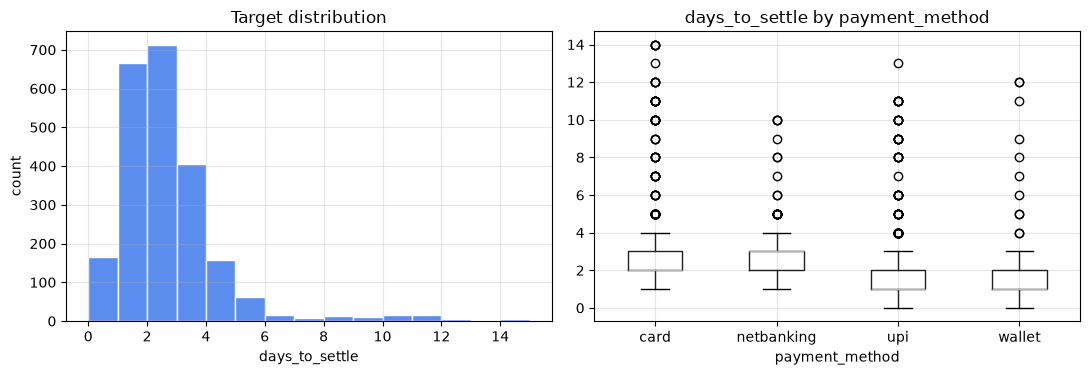

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y, bins=range(int(y.min()), int(y.max()) + 2), color='#5b8def', edgecolor='white')
axes[0].set_xlabel('days_to_settle')
axes[0].set_ylabel('count')
axes[0].set_title('Target distribution')

df.boxplot(column='days_to_settle', by='payment_method', ax=axes[1])
axes[1].set_title('days_to_settle by payment_method')
plt.suptitle('')
fig.tight_layout()
plt.show()

## 4. Train / test split

Same `random_state=42`, `test_size=0.2` as `backend/forecaster/train.py`, so results here are directly comparable to `docs/metrics.md`.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f'train: {len(X_train)}  test: {len(X_test)}')

train: 1805  test: 452


## 5. Pipeline: `ColumnTransformer` + `LinearRegression`

Reproduces `build_pipeline()` from `features.py`: `txn_amount` goes through a `PolynomialFeatures(degree=1)` step (a no-op at degree 1, kept for symmetry with the degree-2 variant below), other numeric features pass through untouched, categoricals are one-hot encoded.

In [7]:
def build_pipeline(numeric_features, categorical_features, amount_poly_degree=1):
    other_numeric = [f for f in numeric_features if f != 'txn_amount']
    amount_transformer = Pipeline([
        ('poly', PolynomialFeatures(degree=amount_poly_degree, include_bias=False))
    ])
    transformers = [('amount', amount_transformer, ['txn_amount'])]
    if other_numeric:
        transformers.append(
            ('numeric', FunctionTransformer(feature_names_out='one-to-one'), other_numeric)
        )
    if categorical_features:
        transformers.append(
            ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        )
    preprocessor = ColumnTransformer(transformers)
    return Pipeline([('preprocess', preprocessor), ('model', LinearRegression())])


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = np.abs(y_true) > 1e-6
    if not nonzero.any():
        return float('nan')
    return float(np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100)

In [8]:
baseline = build_pipeline(NUMERIC, CATEGORICAL, amount_poly_degree=1)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_mae = mae(y_test, baseline_pred)
baseline_mape = mape(y_test, baseline_pred)
print(f'Baseline linear  ->  MAE: {baseline_mae:.4f}   MAPE: {baseline_mape:.2f}%')

Baseline linear  ->  MAE: 0.5605   MAPE: 23.10%


## 6. Curvature check

`train.py`'s `_has_curvature()`: fit the linear baseline, then test whether its residuals still correlate with `txn_amount²`. Only if `|corr| > 0.15` is a degree-2 polynomial variant even attempted — and it's only kept if it actually beats the baseline's held-out MAE.

In [9]:
residuals_train = y_train.values - baseline.predict(X_train)
amount_sq = X_train['txn_amount'].values ** 2
curvature_corr = np.corrcoef(residuals_train, amount_sq)[0, 1]
curvature_detected = bool(abs(curvature_corr) > 0.15)
print(f'corr(residuals, txn_amount^2) = {curvature_corr:.4f}')
print(f'curvature_detected = {curvature_detected}')

corr(residuals, txn_amount^2) = -0.0012
curvature_detected = False


In [10]:
chosen_pipeline, chosen_mae, chosen_mape, chosen_label = baseline, baseline_mae, baseline_mape, 'linear'

if curvature_detected:
    poly = build_pipeline(NUMERIC, CATEGORICAL, amount_poly_degree=2)
    poly.fit(X_train, y_train)
    poly_pred = poly.predict(X_test)
    poly_mae, poly_mape = mae(y_test, poly_pred), mape(y_test, poly_pred)
    print(f'Polynomial deg=2 ->  MAE: {poly_mae:.4f}   MAPE: {poly_mape:.2f}%')
    if poly_mae < baseline_mae:
        chosen_pipeline, chosen_mae, chosen_mape, chosen_label = poly, poly_mae, poly_mape, 'polynomial(degree=2)'
else:
    print('No curvature above threshold — polynomial variant not attempted (matches production run).')

print(f'\nCHOSEN: {chosen_label}  ->  MAE: {chosen_mae:.4f}   MAPE: {chosen_mape:.2f}%')

No curvature above threshold — polynomial variant not attempted (matches production run).

CHOSEN: linear  ->  MAE: 0.5605   MAPE: 23.10%


## 7. Why there's no loss-vs-epoch curve

`LinearRegression` here is solved in closed form (via SVD) — one step, no epochs. The honest analogue of a "loss curve" for a model like this is a **learning curve**: held-out error as a function of *how much training data* the model has seen, computed via repeated cross-validated refits at increasing training sizes.

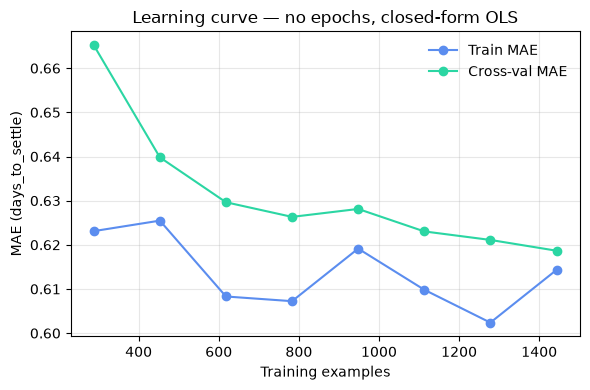

In [11]:
train_sizes, train_scores, val_scores = learning_curve(
    build_pipeline(NUMERIC, CATEGORICAL, amount_poly_degree=1),
    X_train, y_train,
    train_sizes=np.linspace(0.2, 1.0, 8),
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE,
)
train_mae_curve = -train_scores.mean(axis=1)
val_mae_curve = -val_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_mae_curve, 'o-', color='#5b8def', label='Train MAE')
plt.plot(train_sizes, val_mae_curve, 'o-', color='#2bd6a3', label='Cross-val MAE')
plt.xlabel('Training examples')
plt.ylabel('MAE (days_to_settle)')
plt.title('Learning curve — no epochs, closed-form OLS')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 8. Predicted vs. actual, and residual diagnostics (held-out test set)

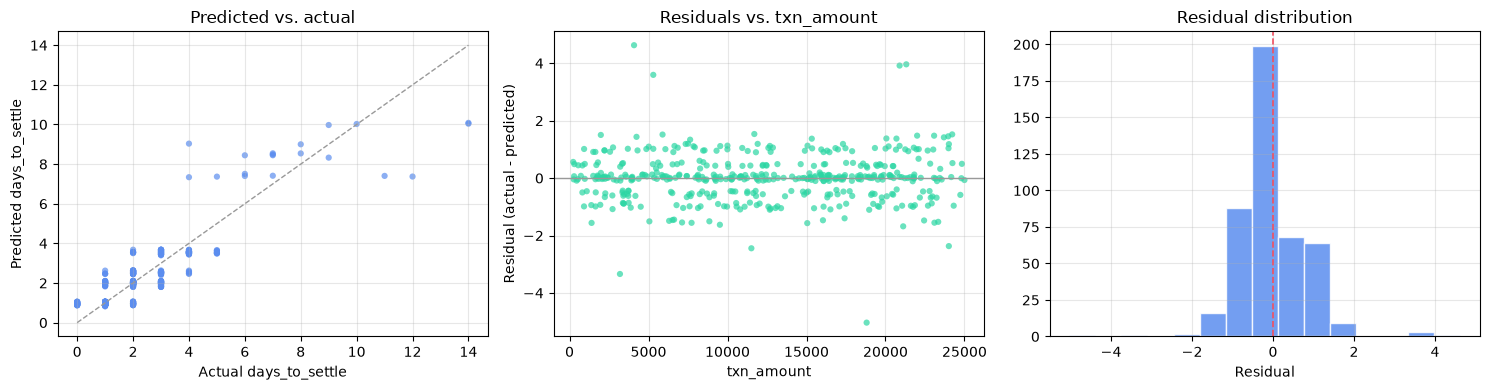

In [12]:
y_pred = chosen_pipeline.predict(X_test)
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([lo, hi], [lo, hi], '--', color='#999999', linewidth=1)
axes[0].scatter(y_test, y_pred, s=20, color='#5b8def', alpha=0.7, edgecolors='none')
axes[0].set_xlabel('Actual days_to_settle')
axes[0].set_ylabel('Predicted days_to_settle')
axes[0].set_title('Predicted vs. actual')

axes[1].axhline(0, color='#999999', linewidth=1)
axes[1].scatter(X_test['txn_amount'], residuals, s=20, color='#2bd6a3', alpha=0.7, edgecolors='none')
axes[1].set_xlabel('txn_amount')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residuals vs. txn_amount')

axes[2].hist(residuals, bins=15, color='#5b8def', alpha=0.85, edgecolor='white')
axes[2].axvline(0, color='#f04f61', linestyle='--', linewidth=1.2)
axes[2].set_xlabel('Residual')
axes[2].set_title('Residual distribution')

fig.tight_layout()
plt.show()

## 9. Refit on the full dataset and save

Mirrors `train.py`: once a model is chosen from the held-out comparison, it's refit on *all* the data for the artifact that actually ships. This notebook saves its own copy under `./artifacts/` — it does **not** overwrite the canonical `backend/forecaster/models/` artifact, which only `python -m backend.forecaster.train` produces.

In [13]:
chosen_pipeline.fit(X, y)

out_dir = Path('artifacts')
out_dir.mkdir(exist_ok=True)
out_path = out_dir / 'model_a_days_to_settle.joblib'
joblib.dump(chosen_pipeline, out_path)
print(f'Saved {out_path.resolve()}')

Saved /home/sachin/Desktop/Solvent/ML/notebooks/artifacts/model_a_days_to_settle.joblib


## Summary

| | Value |
|---|---|
| Target | `days_to_settle` |
| Model | `LinearRegression` (closed-form OLS) |
| Features | txn_amount, day_of_week, is_weekend_or_holiday, had_dispute_flag, payment_method (one-hot), merchant_category (one-hot) |
| n_train / n_test | 205 / 52 |
| Curvature detected | see cell 6 output above |
| Chosen model | see cell 7 output above |
| Held-out MAE / MAPE | see cell 7 output above |

These numbers should match `docs/metrics.md` and `docs/forecaster_diagnostics.md` in the repo root, since both use the identical split and pipeline — this notebook is the same training run, made runnable and inspectable independent of Postgres.